# Allan deviation of white, flicker and random-walk noise

Three synthetic records, one figure. The point of the figure is to let a reader of
chapter 4 look at an Allan-deviation plot and know what its slope means, and to show
why the standard deviation is the wrong summary for a drifting record.

Backs `sec:03_meth_adev` in the thesis. Nothing here is measured data.

| Noise type | acts on $y$ as | $S_y(f)$ | $\sigma_y(\tau)$ |
|---|---|---|---|
| white FM | independent samples | $f^{0}$ | $\tau^{-1/2}$ |
| flicker FM (pink) | correlated at all scales | $f^{-1}$ | $\tau^{0}$ |
| random-walk FM | cumulative | $f^{-2}$ | $\tau^{+1/2}$ |

The series generated below are **fractional frequency** $y(t)$, which is what
`allantools` expects with `data_type='freq'`, and what the thesis's own records are.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import allantools as at
from pathlib import Path

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

FIGDIR = Path('fig')
FIGDIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Everything is dimensionless. The y axes are arbitrary units on purpose, so
# nobody compares these curves against the measured records in chapter 4.
# ---------------------------------------------------------------------------
N        = 8192      # samples per record
RATE     = 1.0       # samples per unit time, so tau is in samples
TAU_REF  = 32.0      # the three curves are scaled to cross here
SEED     = 20260811  # fixed, so the figure is reproducible

LABELS = ['white', 'flicker (pink)', 'random walk']
COLOURS = ['tab:blue', 'tab:orange', 'tab:green']
SLOPES = [-0.5, 0.0, +0.5]


## 1. Generators

Flicker is made by shaping white noise in the frequency domain: the amplitude of each
Fourier component is divided by $\sqrt{f}$, so the power goes as $1/f$. Random walk is
the running sum of white noise, which gives $1/f^2$.


In [2]:
def white_noise(n, rng):
    # Independent Gaussian samples. S_y(f) is flat.
    return rng.standard_normal(n)


def flicker_noise(n, rng):
    # White noise shaped so that S_y(f) goes as 1/f.
    w = rng.standard_normal(n)
    freq = np.fft.rfftfreq(n, d=1.0)
    spec = np.fft.rfft(w)
    shape = np.zeros_like(freq)
    shape[1:] = freq[1:] ** -0.5      # amplitude ~ f^-1/2  ->  power ~ f^-1
    out = np.fft.irfft(spec * shape, n=n)
    return out - out.mean()


def random_walk_noise(n, rng):
    # Running sum of white noise. S_y(f) goes as 1/f^2.
    out = np.cumsum(rng.standard_normal(n))
    return out - out.mean()


GENERATORS = [white_noise, flicker_noise, random_walk_noise]


## 2. Generate, then scale the three records to a common point

Each record is scaled so that its Allan deviation equals one at `TAU_REF`. The three
curves then cross at a single point and the slopes fan out from it, which is the whole
reason the figure is legible. The scaling changes no slope.


In [3]:
rng = np.random.default_rng(SEED)

# Stop well short of the record length. The last few tau are estimated from
# very few differences and bend away from the true slope, which is the
# confidence caveat the thesis states in words rather than draws.
taus_req = np.logspace(0, np.log10(N / 16), 36)

series, curves = [], []
for gen in GENERATORS:
    y = gen(N, rng)
    tau, dev, _, _ = at.oadev(y, rate=RATE, data_type='freq', taus=taus_req)
    # scale so that sigma_y(TAU_REF) == 1
    ref = np.interp(TAU_REF, tau, dev)
    y = y / ref
    tau, dev, _, _ = at.oadev(y, rate=RATE, data_type='freq', taus=taus_req)
    series.append(y)
    curves.append((tau, dev))

print(f'{N} samples per record, seed {SEED}')
for lab, y in zip(LABELS, series):
    print(f'  {lab:16s} record std = {y.std():8.3f}')


8192 samples per record, seed 20260811
  white            record std =    5.935
  flicker (pink)   record std =    2.383
  random walk      record std =   20.646


## 3. Verify the slopes before plotting

A generator that is subtly wrong produces a figure that looks convincing and teaches the
reader the wrong thing. So the slopes are fitted and checked here, not eyeballed later.

The fit uses the middle of the range only. The shortest $\tau$ are biased by the finite
sampling and the longest are estimated from very few differences, so neither end is a
fair test of the slope.


In [4]:
FIT_LO, FIT_HI = 4.0, 256.0

print(f'{"noise":16s} {"fitted":>8s} {"expected":>9s} {"diff":>7s}')
fitted = []
for lab, (tau, dev), want in zip(LABELS, curves, SLOPES):
    m = (tau >= FIT_LO) & (tau <= FIT_HI)
    slope = np.polyfit(np.log10(tau[m]), np.log10(dev[m]), 1)[0]
    fitted.append(slope)
    print(f'{lab:16s} {slope:+8.3f} {want:+9.2f} {slope - want:+7.3f}')

for lab, slope, want in zip(LABELS, fitted, SLOPES):
    assert abs(slope - want) < 0.06, f'{lab}: slope {slope:+.3f}, expected {want:+.2f}'
print('\nall three slopes within 0.06 of the expected value')


noise              fitted  expected    diff
white              -0.517     -0.50  -0.017
flicker (pink)     -0.031     +0.00  -0.031
random walk        +0.493     +0.50  -0.007

all three slopes within 0.06 of the expected value


## 4. The standard deviation does not converge, the Allan deviation does

This is the argument the histogram panel of the figure carries. For white noise the
record standard deviation settles as the record grows. For a random walk it keeps
growing, because every extra sample admits more drift. The Allan deviation is defined on
successive differences and is unaffected.


In [5]:
lengths = [256, 1024, 4096, 8192]

hdr = ' '.join(f'{n:>9d}' for n in lengths)
print(f'{"record std for N =":22s}{hdr}')
for lab, y in zip(LABELS, series):
    row = ' '.join(f'{y[:n].std():9.3f}' for n in lengths)
    print(f'{lab:22s}{row}')

print()
print(f'{"oadev at tau=32 for N =":22s}{hdr}')
for lab, y in zip(LABELS, series):
    vals = []
    for n in lengths:
        t, d, _, _ = at.oadev(y[:n], rate=RATE, data_type='freq', taus=[TAU_REF])
        vals.append(d[0])
    row = ' '.join(f'{v:9.3f}' for v in vals)
    print(f'{lab:22s}{row}')


record std for N =          256      1024      4096      8192
white                     6.149     5.916     5.983     5.935
flicker (pink)            2.154     2.473     2.471     2.383
random walk               1.665     3.136    12.347    20.646

oadev at tau=32 for N =      256      1024      4096      8192
white                     1.184     1.130     1.029     0.995
flicker (pink)            1.235     1.118     1.044     1.000
random walk               0.825     0.781     0.902     1.001


## 5. The figure

Top row: one time trace per noise type, on a shared vertical axis. Bottom left: the three
Allan deviations on one log-log axis with dashed slope guides. Bottom right: the three
distributions, with each record's $\pm1\sigma$ marked.

No power spectral density. The thesis introduces no spectrum before the appendix, and a
PSD panel here would break that.


wrote /Users/nicoschweizer/PyCharmMiscProject/PycharmProjects/Lab/Allan_noise_types/fig/allan_noise_types.pdf


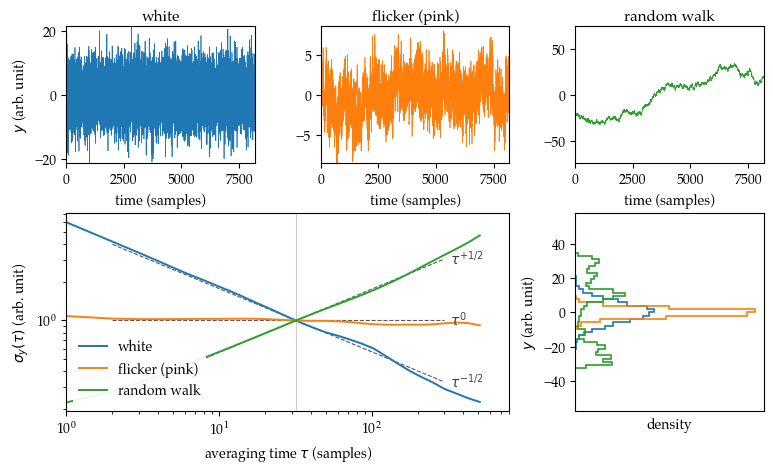

In [19]:
fig = plt.figure(figsize=(9, 5))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.0, 1.45],
              hspace=0.30, wspace=0.35)

# --- top row: one time trace per noise type ------------------------------
t = np.arange(N) / RATE
ylim = 2.8 * max(y.std() for y in series)

for i, (lab, y, col) in enumerate(zip(LABELS, series, COLOURS)):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(t, y, color=col, lw=0.5)
    ax.set_title(lab, fontsize=11, pad=4)
    ax.set_ylim(-3.6 * y.std(), 3.6 * y.std())
    ax.set_xlim(0, t[-1])
    ax.set_xlabel(r'time (samples)', fontsize=10)
    ax.tick_params(labelsize=10)
    if i == 0:
        ax.set_ylabel(r'$y$ (arb. unit)', fontsize=10)

# --- bottom left: the Allan deviations ------------------------------------
ax_a = fig.add_subplot(gs[1, :2])
for lab, (tau, dev), col in zip(LABELS, curves, COLOURS):
    ax_a.loglog(tau, dev, color=col, lw=1.4, label=lab)

guide_tau = np.array([2.0, 300.0])
for want, col, txt in zip(SLOPES, COLOURS,
                          [r'$\tau^{-1/2}$', r'$\tau^{0}$', r'$\tau^{+1/2}$']):
    guide = (guide_tau / TAU_REF) ** want
    ax_a.loglog(guide_tau, guide, color='0.35', lw=0.8, ls='--', zorder=1)
    ax_a.annotate(txt, xy=(guide_tau[-1], guide[-1]), xytext=(4, 0),
                  textcoords='offset points', fontsize=10, color='0.25',
                  va='center')

ax_a.axvline(TAU_REF, color='0.8', lw=0.8, zorder=0)
ax_a.set_xlabel(r'averaging time $\tau$ (samples)', fontsize=10)
ax_a.set_ylabel(r'$\sigma_y(\tau)$ (arb. unit)', fontsize=10)
ax_a.tick_params(labelsize=10)
ax_a.legend(fontsize=10, loc='lower left', frameon=True,
            framealpha=0.92, edgecolor='none')
ax_a.set_xlim(1, 8e2)

# --- bottom right: what the standard deviation sees ------------------------
ax_h = fig.add_subplot(gs[1, 2])
edges = np.linspace(-ylim, ylim, 61)
for lab, y, col in zip(LABELS, series, COLOURS):
    ax_h.hist(y, bins=edges, density=True, histtype='step',
              color=col, lw=1.2, orientation='horizontal')
    #ax_h.axhline(+y.std(), color=col, lw=0.7, ls=':')
    #ax_h.axhline(-y.std(), color=col, lw=0.7, ls=':')

ax_h.set_ylim(-ylim, ylim)
ax_h.set_xlabel('density', fontsize=10)
ax_h.set_ylabel(r'$y$ (arb. unit)', fontsize=10)
ax_h.tick_params(labelsize=10)
ax_h.set_xticks([])

fig.savefig(FIGDIR / 'allan_noise_types.pdf', bbox_inches='tight')
print('wrote', (FIGDIR / 'allan_noise_types.pdf').resolve())
plt.show()


## 6. What the figure is allowed to claim

- The slopes are properties of the estimator, not of this laser. The figure is synthetic
  and the caption has to say so.
- The crossing point at $\tau = 32$ is an artefact of the scaling chosen here. It carries
  no meaning and the caption should not invite a reader to read one off.
- The dotted lines in the histogram are each record's own $\pm1\sigma$. For the random
  walk that number depends on how long the record is, which is exactly the point.
- Real records mix all three, so a measured curve rarely shows a clean single slope.
